# 05 — Single Model Baseline: Optimized Random Forest

**Prinsip desain (berdasarkan karakteristik RF):**
- **Tidak ada scaling** — tree split hanya butuh nilai relatif, bukan jarak
- **Tidak ada PowerTransform** — distribusi natural lebih baik untuk RF
- **Raw integer codes untuk kategoricals** — RF cukup cari split di angka tersebut
- **TargetEncoder untuk nominal high-cardinality** — menggantikan OHE yang menambah dimensi & curse of dimensionality
- **SMOTE dalam imblearn Pipeline** — diterapkan hanya di training fold, bukan validation (anti-leakage)
- **RandomizedSearchCV** — lebih robust dari Optuna untuk RF karena tidak adaptive (tidak overfit ke fold tertentu)
- **Threshold tuning via OOF probs** — bukan dari test set (anti-leakage)

```
Raw CSV
  → Feature Engineering (comprehensive)
  → Train-Test Split (stratified, SEBELUM encoding)
  → imblearn Pipeline:
      ColumnTransformer:
        TargetEncoder (nominal cols, internal cross-fitting anti-leakage)
        Passthrough  (numeric + binary)
      SMOTE (per-fold, anti-leakage)
      RandomForestClassifier
  → RandomizedSearchCV (100 iter, 5-fold, F1 macro, incl. class_weight)
  → Threshold optimization via OOF probabilities
  → Full Evaluation + Feature Importance
```

---
## 0. Setup

In [1]:
import numpy as np
import pandas as pd
import pickle
import warnings
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
warnings.filterwarnings('ignore')

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import (
    train_test_split, StratifiedKFold,
    RandomizedSearchCV, cross_val_predict
)
from sklearn.preprocessing import TargetEncoder
from sklearn.compose import ColumnTransformer
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score,
    accuracy_score, f1_score, precision_score, recall_score
)
from sklearn.base import clone
from scipy.stats import randint, uniform

from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE

RANDOM_STATE = 42
TEST_SIZE    = 0.20
class_names  = ['Graduate', 'Enrolled', 'Dropout']

print("Setup done.")

Setup done.


---
## 1. Load Data
Tidak perlu decode kategorical ke string — RF bekerja langsung dengan integer codes. Nilai integer code tidak bermakna sebagai ordinal, tapi RF hanya cari split point, jadi tidak masalah.

In [2]:
df = pd.read_csv('../data/data.csv', delimiter=';')
df.columns = df.columns.str.strip().str.replace('\t', '')

# Target encoding: Graduate=0, Enrolled=1, Dropout=2
target_map = {'Graduate': 0, 'Enrolled': 1, 'Dropout': 2}
df['target'] = df['Target'].map(target_map)

print(f"Shape: {df.shape}")
print(f"\nClass distribution:")
for k, v in target_map.items():
    n = (df['target'] == v).sum()
    print(f"  {v} → {k}: {n} ({n/len(df)*100:.1f}%)")

print(f"\nDtypes:")
print(df.dtypes)

Shape: (4424, 38)

Class distribution:
  0 → Graduate: 2209 (49.9%)
  1 → Enrolled: 794 (17.9%)
  2 → Dropout: 1421 (32.1%)

Dtypes:
Marital status                                      int64
Application mode                                    int64
Application order                                   int64
Course                                              int64
Daytime/evening attendance                          int64
Previous qualification                              int64
Previous qualification (grade)                    float64
Nacionality                                         int64
Mother's qualification                              int64
Father's qualification                              int64
Mother's occupation                                 int64
Father's occupation                                 int64
Admission grade                                   float64
Displaced                                           int64
Educational special needs                           int

---
## 2. Feature Engineering

**Catatan penting tentang denominator:**  
Menggunakan `+ 1` di denominator menyebabkan systematic bias — misalnya `6 approved / (6 enrolled + 1) = 0.857` padahal harusnya `1.0`. Gunakan `np.where(enrolled > 0, ...)` supaya nilai ratio benar-benar mencerminkan realita.

In [3]:
# Aliases
S1e = df['Curricular units 1st sem (enrolled)']
S1a = df['Curricular units 1st sem (approved)']
S1g = df['Curricular units 1st sem (grade)']
S1v = df['Curricular units 1st sem (evaluations)']
S1c = df['Curricular units 1st sem (credited)']
S1w = df['Curricular units 1st sem (without evaluations)']
S2e = df['Curricular units 2nd sem (enrolled)']
S2a = df['Curricular units 2nd sem (approved)']
S2g = df['Curricular units 2nd sem (grade)']
S2v = df['Curricular units 2nd sem (evaluations)']
S2c = df['Curricular units 2nd sem (credited)']
S2w = df['Curricular units 2nd sem (without evaluations)']

def safe_div(num, den):
    """Division yang benar: return 0 jika denominator=0, bukan num/(den+1)."""
    return np.where(den > 0, num / den, 0.0)

# ── 1. ACADEMIC RATIOS (benar tanpa +1 bias) ──────────────────────────────────
df['success_rate_1st']   = safe_div(S1a, S1e)
df['success_rate_2nd']   = safe_div(S2a, S2e)
df['success_rate_total'] = safe_div(S1a + S2a, S1e + S2e)
df['eval_rate_1st']      = safe_div(S1v, S1e)
df['eval_rate_2nd']      = safe_div(S2v, S2e)
df['without_eval_rate_1st'] = safe_div(S1w, S1e)
df['without_eval_rate_2nd'] = safe_div(S2w, S2e)
df['credit_util_1st']    = safe_div(S1c, S1e)
df['credit_util_2nd']    = safe_div(S2c, S2e)

# ── 2. TRENDS (perubahan dari sem 1 ke sem 2) ─────────────────────────────────
df['grade_improvement']      = S2g - S1g
df['approval_improvement']   = S2a - S1a
df['eval_improvement']       = S2v - S1v
df['success_rate_change']    = df['success_rate_2nd'] - df['success_rate_1st']
df['enrollment_decline']     = (S2e < S1e).astype(int)   # signal dropout: kurangi beban

# ── 3. FAILURE SIGNALS ────────────────────────────────────────────────────────
df['fail_count_1st']     = (S1e - S1a).clip(lower=0)
df['fail_count_2nd']     = (S2e - S2a).clip(lower=0)
df['total_fails']        = df['fail_count_1st'] + df['fail_count_2nd']
df['fail_rate_1st']      = safe_div(df['fail_count_1st'], S1e)
df['fail_rate_2nd']      = safe_div(df['fail_count_2nd'], S2e)
df['is_failing_1st']     = (S1g > 0) & (S1g < 10)       # grade rendah (bukan nol/ghost)
df['is_failing_2nd']     = (S2g > 0) & (S2g < 10)
df['is_failing_1st']     = df['is_failing_1st'].astype(int)
df['is_failing_2nd']     = df['is_failing_2nd'].astype(int)
df['low_approval_1st']   = (df['success_rate_1st'] < 0.5).astype(int)
df['low_approval_2nd']   = (df['success_rate_2nd'] < 0.5).astype(int)
df['zero_eval_1st']      = (S1v == 0).astype(int)         # ghost student signal
df['zero_eval_2nd']      = (S2v == 0).astype(int)
df['zero_eval_both']     = (df['zero_eval_1st'] & df['zero_eval_2nd']).astype(int)
df['has_without_eval_1st'] = (S1w > 0).astype(int)
df['has_without_eval_2nd'] = (S2w > 0).astype(int)
df['dropping_trend']     = ((df['grade_improvement'] < -1) & (df['approval_improvement'] < 0)).astype(int)

# ── 4. COMPOSITE ACADEMIC HEALTH ─────────────────────────────────────────────
# Weighted composite: success rate (40%) + grade normalized (40%) + eval presence (20%)
df['acad_health_1st']    = (
    df['success_rate_1st'] * 0.4 +
    safe_div(S1g, 20) * 0.4 +
    (1 - df['without_eval_rate_1st']) * 0.2
)
df['acad_health_2nd']    = (
    df['success_rate_2nd'] * 0.4 +
    safe_div(S2g, 20) * 0.4 +
    (1 - df['without_eval_rate_2nd']) * 0.2
)
df['acad_trajectory']    = df['acad_health_2nd'] - df['acad_health_1st']
df['grade_avg']          = (S1g + S2g) / 2
df['total_approved']     = S1a + S2a
df['total_enrolled']     = S1e + S2e

# ── 5. GRADE vs ADMISSION BASELINE ────────────────────────────────────────────
# Normalize admission to same 0-20 scale as curricular grades
df['admission_norm']     = df['Admission grade'] / 10        # 0-200 → 0-20
df['prevqual_norm']      = df['Previous qualification (grade)'] / 10
df['grade_vs_admission'] = df['grade_avg'] - df['admission_norm']

# ── 6. FINANCIAL RISK ────────────────────────────────────────────────────────
df['financial_risk']     = (
    (df['Tuition fees up to date'] == 0).astype(int) * 2 +
    df['Debtor'] +
    (df['Scholarship holder'] == 0).astype(int)
)  # 0-4: makin tinggi = makin at-risk
df['tuition_no_scholar'] = (
    (df['Tuition fees up to date'] == 0) & (df['Scholarship holder'] == 0)
).astype(int)
df['debtor_no_scholar']  = (
    (df['Debtor'] == 1) & (df['Scholarship holder'] == 0)
).astype(int)

# ── 7. DEMOGRAPHIC ────────────────────────────────────────────────────────────
df['is_older']           = (df['Age at enrollment'] >= 25).astype(int)
df['is_very_old']        = (df['Age at enrollment'] >= 35).astype(int)

# ── 8. MACRO ─────────────────────────────────────────────────────────────────
df['economic_stress']    = df['Unemployment rate'] * df['Inflation rate']
df['gdp_per_unemp']      = safe_div(df['GDP'], df['Unemployment rate'])

# ── 9. INTERACTION TERMS ──────────────────────────────────────────────────────
df['fail_x_financial']   = df['total_fails']     * df['financial_risk']
df['age_x_financial']    = df['Age at enrollment'] * df['financial_risk']
df['success_x_tuition']  = df['success_rate_total'] * df['Tuition fees up to date']
df['health2_x_financial']= df['acad_health_2nd'] * (4 - df['financial_risk'])

print("Feature engineering done.")
fe_cols = [
    'success_rate_1st', 'success_rate_2nd', 'success_rate_total',
    'eval_rate_1st', 'eval_rate_2nd',
    'without_eval_rate_1st', 'without_eval_rate_2nd',
    'credit_util_1st', 'credit_util_2nd',
    'grade_improvement', 'approval_improvement', 'eval_improvement',
    'success_rate_change', 'enrollment_decline',
    'fail_count_1st', 'fail_count_2nd', 'total_fails',
    'fail_rate_1st', 'fail_rate_2nd',
    'is_failing_1st', 'is_failing_2nd',
    'low_approval_1st', 'low_approval_2nd',
    'zero_eval_1st', 'zero_eval_2nd', 'zero_eval_both',
    'has_without_eval_1st', 'has_without_eval_2nd',
    'dropping_trend',
    'acad_health_1st', 'acad_health_2nd', 'acad_trajectory',
    'grade_avg', 'total_approved', 'total_enrolled',
    'admission_norm', 'prevqual_norm', 'grade_vs_admission',
    'financial_risk', 'tuition_no_scholar', 'debtor_no_scholar',
    'is_older', 'is_very_old',
    'economic_stress', 'gdp_per_unemp',
    'fail_x_financial', 'age_x_financial', 'success_x_tuition', 'health2_x_financial'
]
print(f"Engineered features: {len(fe_cols)}")

Feature engineering done.
Engineered features: 49


---
## 3. Define Feature Groups & Train-Test Split

**Nominal integer codes** (`Marital status`, `Course`, dll): dibiarkan sebagai integer.  
RF tidak peduli urutan — hanya cari split point. TargetEncoder nanti akan mengubahnya menjadi probability-based continuous value yang lebih informatif untuk RF.

In [4]:
# Nominal columns: akan di-TargetEncode
nominal_cols = [
    'Marital status', 'Application mode', 'Course',
    'Previous qualification', 'Nacionality',
    "Mother's qualification", "Father's qualification",
    "Mother's occupation", "Father's occupation"
]

# Numeric & binary: passthrough (no scaling for RF)
passthrough_cols = [
    # Raw numeric
    'Application order',
    'Previous qualification (grade)', 'Admission grade',
    'Age at enrollment',
    'Curricular units 1st sem (credited)', 'Curricular units 1st sem (enrolled)',
    'Curricular units 1st sem (evaluations)', 'Curricular units 1st sem (approved)',
    'Curricular units 1st sem (grade)', 'Curricular units 1st sem (without evaluations)',
    'Curricular units 2nd sem (credited)', 'Curricular units 2nd sem (enrolled)',
    'Curricular units 2nd sem (evaluations)', 'Curricular units 2nd sem (approved)',
    'Curricular units 2nd sem (grade)', 'Curricular units 2nd sem (without evaluations)',
    'Unemployment rate', 'Inflation rate', 'GDP',
    # Raw binary
    'Displaced', 'Educational special needs', 'Debtor',
    'Tuition fees up to date', 'Gender', 'Scholarship holder',
    'International', 'Daytime/evening attendance',
] + fe_cols

all_feature_cols = nominal_cols + passthrough_cols

X = df[all_feature_cols].copy()
y = df['target'].values

# Stratified split SEBELUM encoding
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, stratify=y, random_state=RANDOM_STATE
)

print(f"Total features: {X.shape[1]}")
print(f"  Nominal (TargetEncode): {len(nominal_cols)}")
print(f"  Passthrough           : {len(passthrough_cols)}")
print(f"\nTrain: {X_train.shape} | Test: {X_test.shape}")
print(f"\nClass distribution (train):")
for i, n in enumerate(class_names):
    cnt = (y_train == i).sum()
    print(f"  {n}: {cnt} ({cnt/len(y_train)*100:.1f}%)")

Total features: 85
  Nominal (TargetEncode): 9
  Passthrough           : 76

Train: (3539, 85) | Test: (885, 85)

Class distribution (train):
  Graduate: 1767 (49.9%)
  Enrolled: 635 (17.9%)
  Dropout: 1137 (32.1%)


---
## 4. Build imblearn Pipeline

**Mengapa imblearn Pipeline (bukan sklearn Pipeline)?**  
sklearn Pipeline tidak support SMOTE karena SMOTE mengubah shape data (bukan hanya transform). imblearn Pipeline menangani ini dengan benar: SMOTE hanya diterapkan di training fold, tidak di validation fold.

**Urutan di dalam Pipeline:**
```
ColumnTransformer (TargetEncoder untuk nominal, passthrough untuk sisanya)
  ↓
SMOTE (hanya di training fold, setelah encoding selesai)
  ↓
RandomForestClassifier
```

**Kenapa TargetEncoder sebelum SMOTE?**  
SMOTE butuh semua fitur dalam bentuk numeric untuk interpolasi. TargetEncoder mengubah nominal integers menjadi probabilitas (numeric), sehingga SMOTE bisa interpolasi dengan benar.

In [5]:
# ── ColumnTransformer: TargetEncoder (nominal) + passthrough ──────────────────
# TargetEncoder sklearn >= 1.3:
#   fit_transform() pada training fold menggunakan internal cross-fitting
#   (LOO / k-fold internal) untuk mencegah target leakage
preprocessor = ColumnTransformer(
    transformers=[
        ('te', TargetEncoder(
            target_type='multiclass',
            smooth='auto',
            random_state=RANDOM_STATE
        ), nominal_cols),
        ('pass', 'passthrough', passthrough_cols)
    ],
    remainder='drop',
    verbose_feature_names_out=False
)

# ── Build base pipeline (untuk RandomizedSearchCV) ────────────────────────────
base_pipeline = ImbPipeline(steps=[
    ('preprocessor', preprocessor),
    ('smote', SMOTE(random_state=RANDOM_STATE, k_neighbors=5)),
    ('rf', RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1))
])

print("Pipeline built:")
for name, step in base_pipeline.steps:
    print(f"  [{name}]: {type(step).__name__}")

Pipeline built:
  [preprocessor]: ColumnTransformer
  [smote]: SMOTE
  [rf]: RandomForestClassifier


---
## 5. RandomizedSearchCV — Hyperparameter Tuning

**Mengapa RandomizedSearchCV, bukan Optuna?**  
Optuna menggunakan TPE (adaptive Bayesian search) yang secara iteratif memilih parameter berdasarkan hasil sebelumnya. Dengan dataset kecil dan 5-fold CV yang sama di setiap trial, ada risiko algoritma menemukan parameter yang *kebetulan* cocok untuk 5 fold tersebut, bukan untuk data secara umum.

RandomizedSearchCV memilih parameter secara *random* (non-adaptive), sehingga hasilnya lebih robust dan tidak overfit ke fold tertentu.

**Search space:**
- `class_weight` dimasukkan ke search space (bukan grid terpisah)
- Termasuk `None`, `balanced`, dan 4 variasi custom untuk Enrolled

In [6]:
param_dist = {
    'rf__n_estimators'      : randint(100, 300),
    'rf__max_depth'         : [None, 8, 10, 12, 15, 18, 20, 25],
    'rf__min_samples_leaf'  : randint(1, 15),
    'rf__min_samples_split' : randint(2, 20),
    'rf__max_features'      : ['sqrt', 'log2', 0.2, 0.3, 0.4],
    'rf__criterion'         : ['gini', 'entropy', 'log_loss'],
    'rf__bootstrap'         : [True, False],
    'rf__class_weight'      : [
        None,
        'balanced',
        {0: 1.0, 1: 2.0, 2: 1.5},    # boost Enrolled sedang
        {0: 1.0, 1: 2.5, 2: 1.5},    # boost Enrolled lebih kuat
        {0: 1.0, 1: 3.0, 2: 1.8},    # boost Enrolled kuat
        {0: 0.8, 1: 1.4, 2: 0.85},   # versi user (sedikit berbeda)
        {0: 0.9, 1: 1.8, 2: 1.0},    # fokus Enrolled
    ]
}

cv_strat = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

search = RandomizedSearchCV(
    estimator=base_pipeline,
    param_distributions=param_dist,
    n_iter=30,
    scoring='f1_macro',        # optimize F1 macro (imbalanced problem)
    cv=cv_strat,
    n_jobs=-1,
    random_state=RANDOM_STATE,
    verbose=2,
    refit=True                 # refit terbaik pada seluruh X_train
)

print("Starting RandomizedSearchCV (100 iterations, 5-fold CV)...")
search.fit(X_train, y_train)

print(f"\nBest CV F1 macro  : {search.best_score_:.4f}")
print(f"Best params:")
for k, v in search.best_params_.items():
    print(f"  {k}: {v}")

Starting RandomizedSearchCV (100 iterations, 5-fold CV)...
Fitting 5 folds for each of 30 candidates, totalling 150 fits

Best CV F1 macro  : 0.7241
Best params:
  rf__bootstrap: False
  rf__class_weight: {0: 1.0, 1: 2.0, 2: 1.5}
  rf__criterion: log_loss
  rf__max_depth: None
  rf__max_features: 0.2
  rf__min_samples_leaf: 5
  rf__min_samples_split: 16
  rf__n_estimators: 230


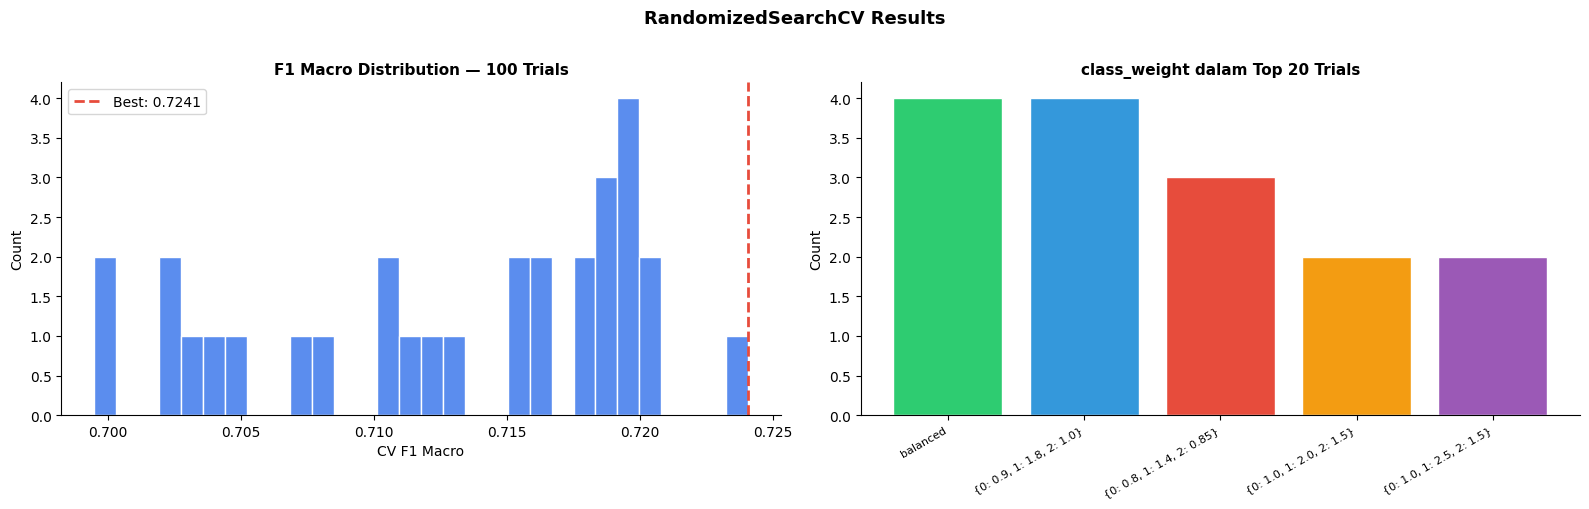

In [7]:
# ── Search results visualization ───────────────────────────────────────────────
cv_results = pd.DataFrame(search.cv_results_)
cv_results_sorted = cv_results.sort_values('mean_test_score', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# F1 distribution across trials
axes[0].hist(cv_results['mean_test_score'], bins=30,
             color='#5b8dee', edgecolor='white')
axes[0].axvline(search.best_score_, color='#e74c3c', linestyle='--', linewidth=2,
                label=f'Best: {search.best_score_:.4f}')
axes[0].set_xlabel('CV F1 Macro'); axes[0].set_ylabel('Count')
axes[0].set_title('F1 Macro Distribution — 100 Trials', fontsize=11, fontweight='bold')
axes[0].legend(); axes[0].spines[['top', 'right']].set_visible(False)

# class_weight distribution in top 20 trials
top20 = cv_results_sorted.head(20)
cw_top = top20['param_rf__class_weight'].astype(str).value_counts()
axes[1].bar(range(len(cw_top)), cw_top.values,
            color=['#2ecc71', '#3498db', '#e74c3c', '#f39c12', '#9b59b6',
                   '#1abc9c', '#e67e22'][:len(cw_top)],
            edgecolor='white')
axes[1].set_xticks(range(len(cw_top)))
axes[1].set_xticklabels([s[:25] for s in cw_top.index], rotation=30, ha='right', fontsize=8)
axes[1].set_title('class_weight dalam Top 20 Trials', fontsize=11, fontweight='bold')
axes[1].set_ylabel('Count'); axes[1].spines[['top', 'right']].set_visible(False)

plt.suptitle('RandomizedSearchCV Results', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

---
## 6. Threshold Optimization via OOF Probabilities

**Kenapa tidak pakai test set untuk tuning threshold?**  
Mencari threshold optimal di test set = test leakage. Model akan terlihat lebih baik dari yang sebenarnya karena threshold-nya "mengetahui" distribusi test set.

**Cara yang benar:** Gunakan Out-of-Fold (OOF) probabilities — probabilitas yang diprediksi di fold validasi selama CV. Model belum melihat data ini saat training, jadi evaluation-nya jujur.

In [8]:
# Get OOF probabilities dari best pipeline (5-fold CV pada X_train)
print("Computing OOF probabilities untuk threshold tuning...")
best_pipeline = search.best_estimator_

# cross_val_predict menggunakan pipeline yang sama (TargetEncoder + SMOTE + RF)
oof_probs = cross_val_predict(
    clone(best_pipeline),
    X_train, y_train,
    cv=StratifiedKFold(5, shuffle=True, random_state=RANDOM_STATE),
    method='predict_proba',
    n_jobs=-1
)

print(f"OOF probs shape: {oof_probs.shape}")

# OOF baseline (default threshold 0.5)
oof_pred_default = oof_probs.argmax(axis=1)
print(f"\nOOF F1 macro (default threshold): {f1_score(y_train, oof_pred_default, average='macro'):.4f}")

# ── Grid search threshold per class (pada OOF, bukan test) ───────────────────
def apply_thresholds(probs, thresholds):
    return (probs - np.array(thresholds)).argmax(axis=1)

best_f1_oof, best_thresh = 0, [1/3, 1/3, 1/3]
grid = np.arange(0.15, 0.65, 0.05)

for t0 in grid:
    for t1 in grid:
        for t2 in grid:
            preds = apply_thresholds(oof_probs, [t0, t1, t2])
            f1 = f1_score(y_train, preds, average='macro')
            if f1 > best_f1_oof:
                best_f1_oof, best_thresh = f1, [t0, t1, t2]

print(f"\nBest thresholds [Graduate, Enrolled, Dropout]: {[round(t,2) for t in best_thresh]}")
print(f"OOF F1 macro with best thresholds            : {best_f1_oof:.4f}")

Computing OOF probabilities untuk threshold tuning...
OOF probs shape: (3539, 3)

OOF F1 macro (default threshold): 0.7241

Best thresholds [Graduate, Enrolled, Dropout]: [np.float64(0.15), np.float64(0.25), np.float64(0.2)]
OOF F1 macro with best thresholds            : 0.7252


---
## 7. Final Evaluation on Test Set

In [9]:
# Predict on test set menggunakan best pipeline (sudah refit pada full X_train)
y_prob_test = best_pipeline.predict_proba(X_test)
y_pred_default = best_pipeline.predict(X_test)
y_pred_tuned   = apply_thresholds(y_prob_test, best_thresh)

print("=" * 65)
print("OPTIMIZED RANDOM FOREST — TEST SET RESULTS")
print("=" * 65)

print("\n--- Default threshold (0.5) ---")
print(classification_report(y_test, y_pred_default, target_names=class_names, digits=4))

print("\n--- Tuned threshold (via OOF, no leakage) ---")
print(classification_report(y_test, y_pred_tuned, target_names=class_names, digits=4))

try:
    print(f"ROC AUC (OvR): {roc_auc_score(y_test, y_prob_test, multi_class='ovr', average='macro'):.4f}")
    print(f"ROC AUC (OvO): {roc_auc_score(y_test, y_prob_test, multi_class='ovo', average='macro'):.4f}")
except Exception as e:
    print(f"AUC: {e}")

# Use tuned prediction as final
y_pred_final = y_pred_tuned
f1s_final    = f1_score(y_test, y_pred_final, average=None)

OPTIMIZED RANDOM FOREST — TEST SET RESULTS

--- Default threshold (0.5) ---
              precision    recall  f1-score   support

    Graduate     0.8582    0.7941    0.8249       442
    Enrolled     0.4615    0.6415    0.5368       159
     Dropout     0.8549    0.7676    0.8089       284

    accuracy                         0.7582       885
   macro avg     0.7249    0.7344    0.7236       885
weighted avg     0.7859    0.7582    0.7680       885


--- Tuned threshold (via OOF, no leakage) ---
              precision    recall  f1-score   support

    Graduate     0.8431    0.8145    0.8285       442
    Enrolled     0.4718    0.5786    0.5198       159
     Dropout     0.8441    0.7817    0.8117       284

    accuracy                         0.7616       885
   macro avg     0.7197    0.7249    0.7200       885
weighted avg     0.7767    0.7616    0.7677       885

ROC AUC (OvR): 0.8952
ROC AUC (OvO): 0.8853


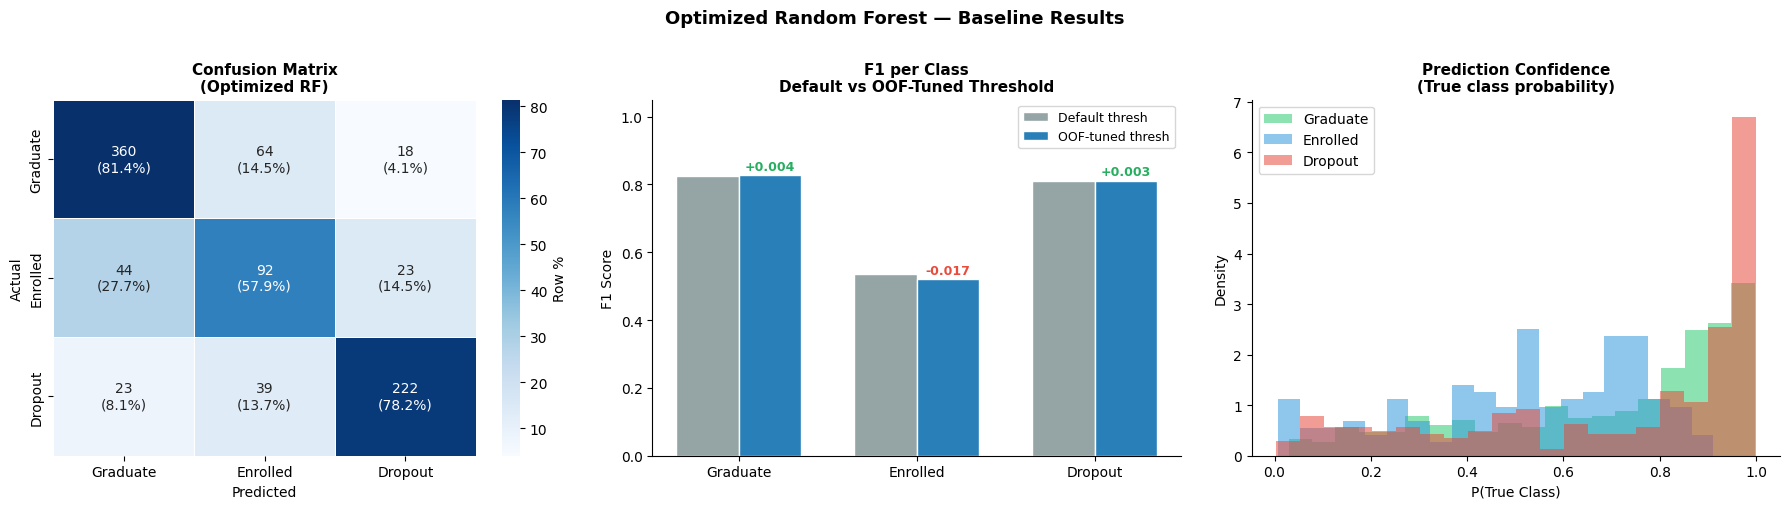

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Confusion matrix
cm     = confusion_matrix(y_test, y_pred_final)
cm_pct = cm.astype(float) / cm.sum(axis=1, keepdims=True) * 100
annot  = np.array([[f"{c}\n({p:.1f}%)" for c, p in zip(rc, rp)]
                    for rc, rp in zip(cm, cm_pct)])
sns.heatmap(cm_pct, ax=axes[0], annot=annot, fmt='', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names,
            linewidths=0.5, cbar_kws={'label': 'Row %'})
axes[0].set_title('Confusion Matrix\n(Optimized RF)', fontsize=11, fontweight='bold')
axes[0].set_ylabel('Actual'); axes[0].set_xlabel('Predicted')

# Default vs Tuned threshold comparison
f1_default = f1_score(y_test, y_pred_default, average=None)
f1_tuned   = f1s_final
x = np.arange(3); w = 0.35
axes[1].bar(x - w/2, f1_default, w, label='Default thresh', color='#95a5a6', edgecolor='white')
axes[1].bar(x + w/2, f1_tuned,   w, label='OOF-tuned thresh', color='#2980b9', edgecolor='white')
axes[1].set_xticks(x); axes[1].set_xticklabels(class_names)
axes[1].set_ylabel('F1 Score'); axes[1].set_ylim(0, 1.05)
axes[1].set_title('F1 per Class\nDefault vs OOF-Tuned Threshold', fontsize=11, fontweight='bold')
axes[1].legend(fontsize=9); axes[1].spines[['top', 'right']].set_visible(False)
for i, (d, t) in enumerate(zip(f1_default, f1_tuned)):
    delta = t - d
    col   = '#27ae60' if delta >= 0 else '#e74c3c'
    axes[1].text(i + w/2, t + 0.015, f'{delta:+.3f}',
                 ha='center', fontsize=9, color=col, fontweight='bold')

# Confidence distribution
for i, (cls, col) in enumerate(zip(class_names, ['#2ecc71', '#3498db', '#e74c3c'])):
    axes[2].hist(y_prob_test[y_test == i, i], bins=20, alpha=0.55,
                 density=True, color=col, label=cls)
axes[2].set_xlabel('P(True Class)'); axes[2].set_ylabel('Density')
axes[2].set_title('Prediction Confidence\n(True class probability)', fontsize=11, fontweight='bold')
axes[2].legend(); axes[2].spines[['top', 'right']].set_visible(False)

plt.suptitle('Optimized Random Forest — Baseline Results', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

---
## 8. Feature Importance

Top 25 Features:
                            Feature  Importance
                  success_x_tuition    0.094386
                   fail_x_financial    0.064354
                health2_x_financial    0.058356
                 success_rate_total    0.051889
                        total_fails    0.049457
                   success_rate_2nd    0.038327
                      fail_rate_2nd    0.035447
                    acad_health_2nd    0.028649
                     fail_count_2nd    0.024701
                      eval_rate_2nd    0.019499
                           Course_1    0.015396
              Mother's occupation_2    0.014002
                    age_x_financial    0.013829
Curricular units 2nd sem (approved)    0.012909
Curricular units 1st sem (approved)    0.012529
                           Course_2    0.012054
                           Course_0    0.011760
                      eval_rate_1st    0.011617
                     fail_count_1st    0.010924
           Mother's qua

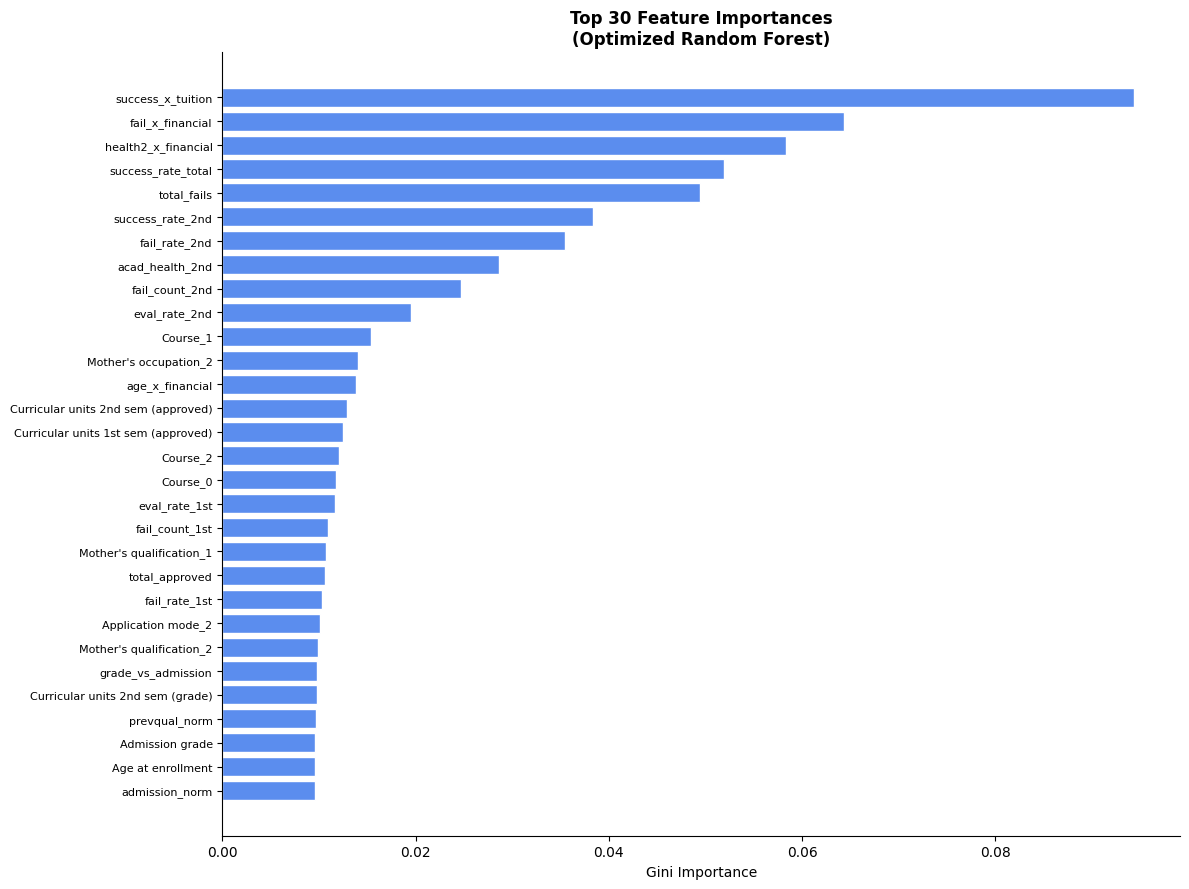

In [11]:
# Get feature names setelah ColumnTransformer
try:
    feat_names = (
        list(best_pipeline.named_steps['preprocessor']
             .get_feature_names_out())
    )
except:
    # Fallback: TargetEncoder multiclass output = n_cats × n_classes columns for each nominal
    feat_names = [f'feat_{i}' for i in range(
        best_pipeline.named_steps['rf'].n_features_in_
    )]

importances = best_pipeline.named_steps['rf'].feature_importances_

fi_df = pd.DataFrame({
    'Feature'   : feat_names[:len(importances)],
    'Importance': importances
}).sort_values('Importance', ascending=False).reset_index(drop=True)

print("Top 25 Features:")
print(fi_df.head(25).to_string(index=False))

fig, ax = plt.subplots(figsize=(12, 9))
top30 = fi_df.head(30)
ax.barh(range(len(top30)), top30['Importance'][::-1].values,
        color='#5b8dee', edgecolor='white')
ax.set_yticks(range(len(top30)))
ax.set_yticklabels(top30['Feature'][::-1].values, fontsize=8)
ax.set_xlabel('Gini Importance')
ax.set_title('Top 30 Feature Importances\n(Optimized Random Forest)', fontsize=12, fontweight='bold')
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()

---
## 9. Summary & Save Baseline

In [ ]:
baseline = {
    'model'            : 'RandomForest (RandomizedSearchCV + OOF threshold)',
    'pipeline'         : best_pipeline,
    'best_params'      : search.best_params_,
    'best_thresh'      : best_thresh,
    'cv_f1_macro'      : search.best_score_,
    'oof_f1_macro'     : best_f1_oof,
    'test_accuracy'    : accuracy_score(y_test, y_pred_final),
    'test_f1_macro'    : f1_score(y_test, y_pred_final, average='macro'),
    'test_f1_weighted' : f1_score(y_test, y_pred_final, average='weighted'),
    'f1_per_class'     : dict(zip(class_names, f1s_final)),
    'precision_per_class': dict(zip(class_names, precision_score(y_test, y_pred_final, average=None))),
    'recall_per_class' : dict(zip(class_names, recall_score(y_test, y_pred_final, average=None))),
    'y_pred'           : y_pred_final,
    'y_prob'           : y_prob_test,
    'y_test'           : y_test,
    'class_names'      : class_names,
    'feature_importance': fi_df
}
try:
    baseline['roc_auc_ovr'] = roc_auc_score(y_test, y_prob_test, multi_class='ovr', average='macro')
except: pass

with open('../data/baseline_bundle.pkl', 'wb') as f:
    pickle.dump(baseline, f)

print("Saved: ../data/baseline_bundle.pkl")
print()
print("=" * 65)
print("OPTIMIZED RANDOM FOREST — FINAL BASELINE SUMMARY")
print("=" * 65)
print(f"  RandomizedSearchCV  : 30 iterations, 5-fold CV, F1 macro")
print(f"  SMOTE               : dalam setiap training fold (anti-leakage)")
print(f"  TargetEncoder       : nominal cols, internal cross-fitting")
print(f"  Threshold tuning    : via OOF probabilities (anti-leakage)")
print(f"  Scaling             : NONE (RF tidak butuh scaling)")
print(f"  Total features      : {len(feat_names[:len(importances)])}")
print(f"  class_weight        : {search.best_params_.get('rf__class_weight')}")
print()
print(f"  CV F1 macro         : {baseline['cv_f1_macro']:.4f}")
print(f"  OOF F1 macro        : {baseline['oof_f1_macro']:.4f}")
print(f"  Accuracy            : {baseline['test_accuracy']:.4f}")
print(f"  F1 macro            : {baseline['test_f1_macro']:.4f}")
print(f"  F1 weighted         : {baseline['test_f1_weighted']:.4f}")
print()
print(f"  {'Class':<12} {'F1':>8} {'Precision':>12} {'Recall':>10}")
print(f"  {'-'*46}")
for cls in class_names:
    print(f"  {cls:<12} "
          f"{baseline['f1_per_class'][cls]:>8.4f} "
          f"{baseline['precision_per_class'][cls]:>12.4f} "
          f"{baseline['recall_per_class'][cls]:>10.4f}")
try:
    print(f"\n  ROC AUC OvR         : {baseline['roc_auc_ovr']:.4f}")
except: pass

Saved: ../data/baseline_bundle.pkl

OPTIMIZED RANDOM FOREST — FINAL BASELINE SUMMARY
  RandomizedSearchCV  : 100 iterations, 5-fold CV, F1 macro
  SMOTE               : dalam setiap training fold (anti-leakage)
  TargetEncoder       : nominal cols, internal cross-fitting
  Threshold tuning    : via OOF probabilities (anti-leakage)
  Scaling             : NONE (RF tidak butuh scaling)
  Total features      : 103
  class_weight        : {0: 1.0, 1: 2.0, 2: 1.5}

  CV F1 macro         : 0.7241
  OOF F1 macro        : 0.7252
  Accuracy            : 0.7616
  F1 macro            : 0.7200
  F1 weighted         : 0.7677

  Class              F1    Precision     Recall
  ----------------------------------------------
  Graduate       0.8285       0.8431     0.8145
  Enrolled       0.5198       0.4718     0.5786
  Dropout        0.8117       0.8441     0.7817

  ROC AUC OvR         : 0.8952
